# Кейс 7. Аддитивная модель по мотивам теоремы Колмогорова

## 1. Импорты

In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from shared.metrics import mse, rmse, r2_score
from shared.utils import min_max_scale
from case_7.src.additive import AdditiveModel, FullNonLinearModel

import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs("plots", exist_ok=True)

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black"
})

## 2. Генерация синтетических данных

In [3]:
np.random.seed(42)
N = 300
X_add = np.random.uniform(0, 1, size=(N, 3))
# y = sin(2*pi*x1) + 0.5*(x2 - 0.5)^2 + exp(-3*x3) + eps
y_add = np.sin(2 * np.pi * X_add[:, 0]) + 0.5 * (X_add[:, 1] - 0.5)**2 + np.exp(-3 * X_add[:, 2]) + np.random.normal(0, 0.1, N)

X_nonadd = np.random.uniform(0, 1, size=(N, 3))
# Неаддитивная зависимость
y_nonadd = np.sin(2 * np.pi * (X_nonadd[:, 0] + X_nonadd[:, 1])) + 0.5 * X_nonadd[:, 2] + np.random.normal(0, 0.1, N)

## 3. Обучение аддитивной модели и интерпретация компонент

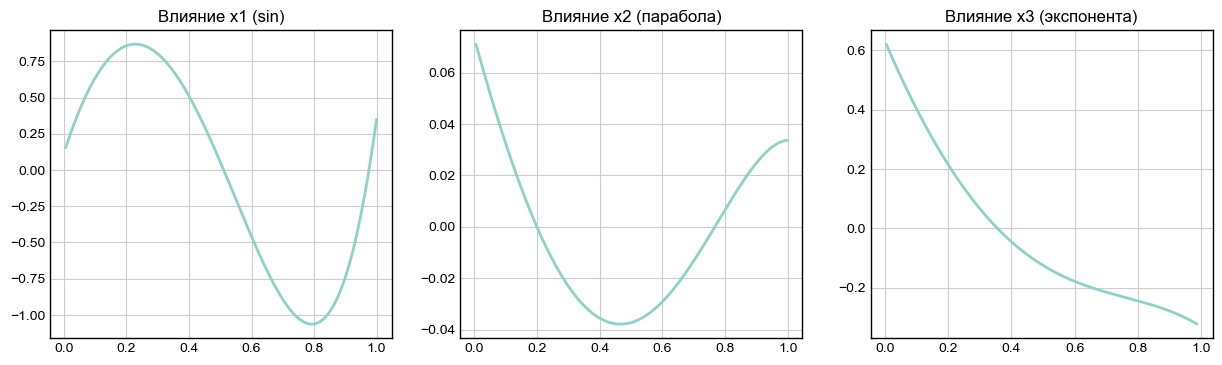

In [4]:
# Обучение модели с полиномиальным базисом
add_model = AdditiveModel(M=5, basis='poly', alpha=0.01).fit(X_add, y_add)

# Извлекаем функции g_j(x)
X_test_sorted = np.sort(X_add, axis=0) # сортируем для графиков
_, components = add_model.predict_components(X_test_sorted)

plt.figure(figsize=(15, 4))
titles = ["Влияние x1 (sin)", "Влияние x2 (парабола)", "Влияние x3 (экспонента)"]
for j in range(3):
    plt.subplot(1, 3, j+1)
    plt.plot(X_test_sorted[:, j], components[j], linewidth=2)
    plt.title(titles[j])
    plt.grid(True)
plt.savefig("plots/01_additive_components_influence.png", dpi=100, bbox_inches='tight')
plt.show()

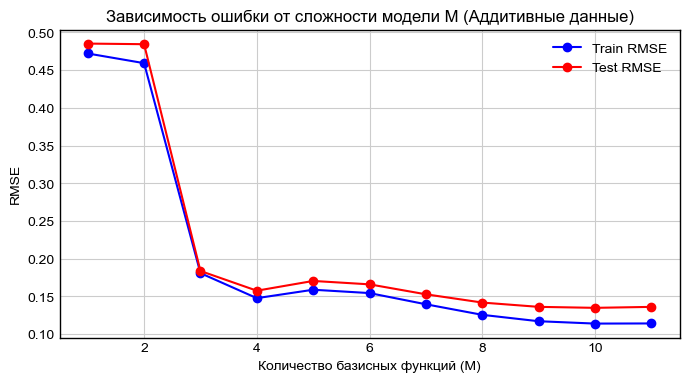

In [5]:
X_train_add, X_test_add, y_train_add, y_test_add = train_test_split(X_add, y_add, test_size=0.2, random_state=42)

# Исследование влияния M (базисных функций) на ошибку
M_values = range(1, 12)
rmse_train = []
rmse_test = []

for m in M_values:
    # Обучаем аддитивную модель
    model_m = AdditiveModel(M=m, basis='poly', alpha=0.01).fit(X_train_add, y_train_add)

    rmse_train.append(rmse(y_train_add, model_m.predict(X_train_add)))
    rmse_test.append(rmse(y_test_add, model_m.predict(X_test_add)))

plt.figure(figsize=(8, 4))
plt.plot(M_values, rmse_train, label='Train RMSE', marker='o', color='blue')
plt.plot(M_values, rmse_test, label='Test RMSE', marker='o', color='red')
plt.xlabel('Количество базисных функций (M)')
plt.ylabel('RMSE')
plt.title("Зависимость ошибки от сложности модели M (Аддитивные данные)")
plt.legend()
plt.grid(True)
plt.savefig("plots/02_rmse_vs_m_complexity.png", dpi=100, bbox_inches='tight')
plt.show()

## 4. Сравнение с Линейной и Полной Нелинейной моделями

In [6]:
def eval_model(model, X, y):
    preds = model.predict(X)
    return mse(y, preds), rmse(y, preds), r2_score(y, preds)

In [7]:
# Подготовка Diabetes (нормализация признаков в [0, 1])
diabetes = load_diabetes()
X_db_scaled = min_max_scale(diabetes.data)
y_db = diabetes.target
X_tr_db, X_te_db, y_tr_db, y_te_db = train_test_split(X_db_scaled, y_db, test_size=0.2, random_state=42)

# Обучение трех моделей на Diabetes
db_lin = AdditiveModel(M=1, basis='poly').fit(X_tr_db, y_tr_db)
db_add = AdditiveModel(M=3, basis='poly', alpha=0.1).fit(X_tr_db, y_tr_db)
db_full = FullNonLinearModel(degree=2, alpha=0.1).fit(X_tr_db, y_tr_db)

# Подготовка California Housing
housing = fetch_california_housing()
X_hs_scaled = min_max_scale(housing.data)
y_hs = housing.target
X_tr_hs, X_te_hs, y_tr_hs, y_te_hs = train_test_split(X_hs_scaled, y_hs, test_size=0.2, random_state=42)

# Обучение трех моделей на California Housing
hs_lin = AdditiveModel(M=1, basis='poly').fit(X_tr_hs, y_tr_hs)
hs_add = AdditiveModel(M=3, basis='poly', alpha=0.1).fit(X_tr_hs, y_tr_hs)
hs_full = FullNonLinearModel(degree=2, alpha=0.1).fit(X_tr_hs, y_tr_hs)

# Метрики
# Diabetes
mse_db_lin, rmse_db_lin, r2_db_lin = eval_model(db_lin, X_te_db, y_te_db)
mse_db_add, rmse_db_add, r2_db_add = eval_model(db_add, X_te_db, y_te_db)
mse_db_full, rmse_db_full, r2_db_full = eval_model(db_full, X_te_db, y_te_db)

# California Housing
mse_hs_lin, rmse_hs_lin, r2_hs_lin = eval_model(hs_lin, X_te_hs, y_te_hs)
mse_hs_add, rmse_hs_add, r2_hs_add = eval_model(hs_add, X_te_hs, y_te_hs)
mse_hs_full, rmse_hs_full, r2_hs_full = eval_model(hs_full, X_te_hs, y_te_hs)

df_real_db = pd.DataFrame({
    "Модель": ["Линейная", "Аддитивная", "Полная нелинейная (deg=2)"],
    "MSE": [mse_db_lin, mse_db_add, mse_db_full],
    "RMSE": [rmse_db_lin, rmse_db_add, rmse_db_full],
    "R^2": [r2_db_lin, r2_db_add, r2_db_full]
})

df_real_hs = pd.DataFrame({
    "Модель": ["Линейная", "Аддитивная", "Полная нелинейная (deg=2)"],
    "MSE": [mse_hs_lin, mse_hs_add, mse_hs_full],
    "RMSE": [rmse_hs_lin, rmse_hs_add, rmse_hs_full],
    "R^2": [r2_hs_lin, r2_hs_add, r2_hs_full]
})

display(HTML("<h3>Метрики моделей на реальном датасете: Diabetes</h3>"))
display(df_real_db.style.format({"MSE": "{:.4f}", "RMSE": "{:.4f}", "R^2": "{:.4f}"}).hide(axis="index"))

display(HTML("<h3>Метрики моделей на реальном датасете: California Housing</h3>"))
display(df_real_hs.style.format({"MSE": "{:.4f}", "RMSE": "{:.4f}", "R^2": "{:.4f}"}).hide(axis="index"))

Модель,MSE,RMSE,R^2
Линейная,2900.1936,53.8534,0.4526
Аддитивная,2777.3285,52.7004,0.4758
Полная нелинейная (deg=2),2565.6967,50.6527,0.5157


Модель,MSE,RMSE,R^2
Линейная,0.5559,0.7456,0.5758
Аддитивная,0.5139,0.7169,0.6079
Полная нелинейная (deg=2),0.5067,0.7118,0.6133
